# AgroPredict — Módulo 1: Preparación de datos de rendimiento (Maíz)

Este notebook toma las **Evaluaciones Agropecuarias Municipales (EVA)** del MADR (2006–2018)
y construye una tabla limpia y lista para modelar el **rendimiento del maíz** en Colombia.

**Qué hace, paso a paso:**
1. Carga el CSV con el tipado correcto (¡ojo con el separador de miles!).
2. Filtra a maíz y separa sus dos sistemas productivos (tradicional / tecnificado).
3. Limpia: normaliza códigos geográficos, recupera rendimientos faltantes, corrige errores lógicos y acota valores atípicos.
4. Separa los **siniestros** (sembrado sin cosecha) como insumo para el módulo de riesgo.
5. Explora los datos con gráficas.
6. Exporta el dataset analítico final.

> **Unidad de análisis (grano):** un registro = un cultivo, en un municipio, en un año y semestre.
> Esta es la tabla a la que luego le "pegaremos" el clima (NASA POWER), el suelo (SoilGrids) y los precios (SIPSA).

## 0. Configuración e importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# === AJUSTA ESTA RUTA a donde tengas el archivo en tu computador ===
CSV_PATH = "Evaluaciones_Agropecuarias_Municipales_EVA_20260608.csv"
CULTIVO_OBJETIVO = "MAIZ"
DIR_SALIDA = "datos_procesados"
os.makedirs(DIR_SALIDA, exist_ok=True)

print("Configuración lista. Cultivo objetivo:", CULTIVO_OBJETIVO)

Configuración lista. Cultivo objetivo: MAIZ


## 1. Carga y tipado de datos

El archivo original tiene dos particularidades que hay que manejar sí o sí:

- Los **nombres de columna** traen saltos de línea y acentos → los reemplazamos por nombres limpios.
- Los **números usan la coma como separador de miles** (p. ej. `"2,006"` es el año 2006 y `"1,440"` son 1.440 t),
  y el punto como decimal. Por eso usamos `thousands=','` al leer.

In [2]:
# Nombres de columna limpios (en el mismo orden del archivo)
COLUMNAS = ['cod_dep','departamento','cod_mun','municipio','grupo_cultivo',
            'subgrupo_cultivo','cultivo','desagregacion','anio','periodo',
            'area_sembrada_ha','area_cosechada_ha','produccion_t','rendimiento_tha',
            'estado_fisico','nombre_cientifico','ciclo_cultivo']

df = pd.read_csv(CSV_PATH, thousands=',', dtype=str)
df.columns = COLUMNAS

# Convertir las medidas a numérico (quitando comas remanentes por seguridad)
columnas_numericas = ['area_sembrada_ha','area_cosechada_ha','produccion_t','rendimiento_tha']
for c in columnas_numericas:
    df[c] = pd.to_numeric(df[c].str.replace(',', '', regex=False), errors='coerce')
df['anio'] = pd.to_numeric(df['anio'].str.replace(',', '', regex=False), errors='coerce').astype('Int64')

print(f"Registros totales (todos los cultivos): {len(df):,}")
print(f"Años: {df['anio'].min()}-{df['anio'].max()}  |  Cultivos distintos: {df['cultivo'].nunique()}")
df.head(3)

Registros totales (todos los cultivos): 206,068
Años: 2006-2018  |  Cultivos distintos: 223


,cod_dep,departamento,cod_mun,municipio,grupo_cultivo,subgrupo_cultivo,cultivo,desagregacion,anio,periodo,area_sembrada_ha,area_cosechada_ha,produccion_t,rendimiento_tha,estado_fisico,nombre_cientifico,ciclo_cultivo
0,15,BOYACA,"15,114",BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,2,1,1,1.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,"25,754",SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,82,80,1440,18.00,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,"25,214",COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2006,2006B,2,2,26,17.33,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO


## 2. Filtrado a maíz

El maíz es un cultivo **transitorio**, por lo que cada año tiene dos cosechas: semestre **A** y semestre **B**.
Esa marca está dentro de la columna `periodo` (p. ej. `2010A`, `2010B`) y la extraemos a una columna propia,
porque más adelante el clima debe agregarse por *ese* semestre, no por el año completo.

In [3]:
maiz = df[df['cultivo'] == CULTIVO_OBJETIVO].copy()
print(f"Registros de {CULTIVO_OBJETIVO}: {len(maiz):,}\n")

print("Sistema productivo (desagregación):")
print(maiz['desagregacion'].value_counts().to_string())

# Extraer el semestre (letra final del periodo) a su propia columna
maiz['semestre'] = maiz['periodo'].str.extract(r'(\D)$')[0]
print("\nRegistros por semestre:")
print(maiz['semestre'].value_counts().to_string())

Registros de MAIZ: 24,965

Sistema productivo (desagregación):
desagregacion
MAIZ TRADICIONAL    20069
MAIZ TECNIFICADO     4896

Registros por semestre:
semestre
A    13410
B    11555


## 3. Limpieza

Trabajamos los cinco problemas que detectamos en el diagnóstico, en orden.

### 3.1 Normalizar códigos geográficos

Antioquia venía como `"5"` y Atlántico como `"8"`, cuando los códigos DANE son `"05"` y `"08"`.
Rellenamos con ceros a la izquierda: **2 dígitos** el departamento y **5 dígitos** el municipio.
Esto es indispensable para que después los códigos crucen con mapas/centroides y con las fuentes de clima.

In [4]:
maiz['cod_dep'] = maiz['cod_dep'].str.replace(',', '', regex=False).str.zfill(2)
maiz['cod_mun'] = maiz['cod_mun'].str.replace(',', '', regex=False).str.zfill(5)

print("Departamentos (ej.):", sorted(maiz['cod_dep'].unique())[:6])
print("Municipios (ej.):", list(maiz['cod_mun'].unique()[:3]))
print("Antioquia ahora es '05' y Atlántico '08'.")

Departamentos (ej.): ['05', '08', '13', '15', '17', '18']
Municipios (ej.): ['05051', '05101', '05842']
Antioquia ahora es '05' y Atlántico '08'.


### 3.2 Recuperar rendimientos faltantes

Donde falte el rendimiento pero sí haya área cosechada y producción, lo **recalculamos** como
`producción / área cosechada` en lugar de descartar la fila.

In [5]:
faltantes_antes = maiz['rendimiento_tha'].isna().sum()
recuperables = maiz['rendimiento_tha'].isna() & (maiz['area_cosechada_ha'] > 0)
maiz.loc[recuperables, 'rendimiento_tha'] = (
    maiz.loc[recuperables, 'produccion_t'] / maiz.loc[recuperables, 'area_cosechada_ha']
)

print(f"Rendimientos faltantes al inicio: {faltantes_antes}")
print(f"Recuperados con producción/área: {recuperables.sum()}")
print(f"Faltantes restantes (sin área cosechada): {maiz['rendimiento_tha'].isna().sum()}")

Rendimientos faltantes al inicio: 48
Recuperados con producción/área: 0
Faltantes restantes (sin área cosechada): 48


### 3.3 Corregir errores lógicos

Dos situaciones imposibles: área cosechada mayor que la sembrada, y producción positiva con cosecha en cero.
Las **marcamos** con una bandera para excluirlas del set de entrenamiento.

In [6]:
err_area = maiz['area_cosechada_ha'] > maiz['area_sembrada_ha']
err_prod = (maiz['produccion_t'] > 0) & (maiz['area_cosechada_ha'] == 0)
maiz['error_logico'] = err_area | err_prod

print(f"Área cosechada > sembrada: {err_area.sum()} filas")
print(f"Producción > 0 con cosecha = 0: {err_prod.sum()} filas")
print(f"Total marcadas como error lógico: {maiz['error_logico'].sum()}")

Área cosechada > sembrada: 2 filas
Producción > 0 con cosecha = 0: 4 filas
Total marcadas como error lógico: 6


### 3.4 Separar siniestros (señal de riesgo)

Las filas con área sembrada pero **cosecha = 0** representan pérdidas totales (siniestros).
Estorban para predecir rendimiento (división por cero), pero son **oro para el módulo de riesgo climático**:
son justo el evento "sembré y perdí" que la app quiere anticipar. Las guardamos aparte.

In [7]:
siniestros = maiz[(maiz['area_cosechada_ha'] == 0) & (~maiz['error_logico'])].copy()
print(f"Siniestros de maíz (sembrado, cosecha = 0): {len(siniestros):,}")
print("Se reservan para el módulo de RIESGO, no para el de rendimiento.")

Siniestros de maíz (sembrado, cosecha = 0): 61
Se reservan para el módulo de RIESGO, no para el de rendimiento.


### 3.5 Acotar valores atípicos (por sistema productivo)

El maíz tecnificado rinde mucho más que el tradicional, así que mezclarlos para recortar outliers
distorsiona el resultado. Aplicamos **winsorización (percentiles 1 y 99) dentro de cada sistema**:
los valores extremos se "pegan" al límite en vez de eliminarse.

In [8]:
# Base analítica: cosecha válida, rendimiento válido y sin errores lógicos
base = maiz[(maiz['area_cosechada_ha'] > 0) &
            (maiz['rendimiento_tha'].notna()) &
            (~maiz['error_logico'])].copy()

def winsorizar(serie, p_bajo=0.01, p_alto=0.99):
    lo, hi = serie.quantile([p_bajo, p_alto])
    return serie.clip(lo, hi)

base['rendimiento_tha'] = base.groupby('desagregacion')['rendimiento_tha'].transform(winsorizar)

print("Rendimiento por sistema tras winsorización:")
print(base.groupby('desagregacion')['rendimiento_tha']
          .agg(['count', 'min', 'mean', 'max']).round(2).to_string())

Rendimiento por sistema tras winsorización:
                  count  min  mean  max
desagregacion                          
MAIZ TECNIFICADO   4887  1.0  3.95  8.0
MAIZ TRADICIONAL  20011  0.4  1.47  3.0


## 4. Dataset analítico final

Nos quedamos con las columnas relevantes para el modelo. Conservamos `desagregacion` (tradicional/tecnificado)
y `semestre` porque serán variables predictoras importantes.

In [9]:
columnas_modelo = ['cod_dep', 'departamento', 'cod_mun', 'municipio',
                   'cultivo', 'desagregacion', 'ciclo_cultivo',
                   'anio', 'periodo', 'semestre',
                   'area_sembrada_ha', 'area_cosechada_ha', 'produccion_t', 'rendimiento_tha']
maiz_final = base[columnas_modelo].reset_index(drop=True)

print(f"DATASET FINAL DE MAÍZ: {len(maiz_final):,} filas")
print(f"  Periodo: {maiz_final['anio'].min()}-{maiz_final['anio'].max()}")
print(f"  Departamentos: {maiz_final['departamento'].nunique()}  |  Municipios: {maiz_final['cod_mun'].nunique()}")
print(f"  Rendimiento medio: {maiz_final['rendimiento_tha'].mean():.2f} t/ha "
      f"(mediana {maiz_final['rendimiento_tha'].median():.2f})")
maiz_final.head()

DATASET FINAL DE MAÍZ: 24,898 filas
  Periodo: 2006-2018
  Departamentos: 32  |  Municipios: 1063
  Rendimiento medio: 1.96 t/ha (mediana 1.50)


,cod_dep,departamento,cod_mun,municipio,cultivo,desagregacion,ciclo_cultivo,anio,periodo,semestre,area_sembrada_ha,area_cosechada_ha,produccion_t,rendimiento_tha
0,05,ANTIOQUIA,05051,ARBOLETES,MAIZ,MAIZ TECNIFICADO,TRANSITORIO,2006,2006B,B,4800,4650,11625,2.5
1,05,ANTIOQUIA,05101,CIUDAD BOLIVAR,MAIZ,MAIZ TECNIFICADO,TRANSITORIO,2006,2006B,B,450,450,1350,3.0
2,05,ANTIOQUIA,05842,URAMITA,MAIZ,MAIZ TECNIFICADO,TRANSITORIO,2006,2006B,B,405,180,630,3.5
3,05,ANTIOQUIA,05380,LA ESTRELLA,MAIZ,MAIZ TECNIFICADO,TRANSITORIO,2006,2006B,B,3,3,12,4.0
4,13,BOLIVAR,13442,MARIA LA BAJA,MAIZ,MAIZ TECNIFICADO,TRANSITORIO,2006,2006B,B,2030,2030,7105,3.5


## 5. Análisis exploratorio

Cinco vistas para entender el maíz antes de modelar.

**5.1 Evolución del rendimiento por año y sistema productivo**

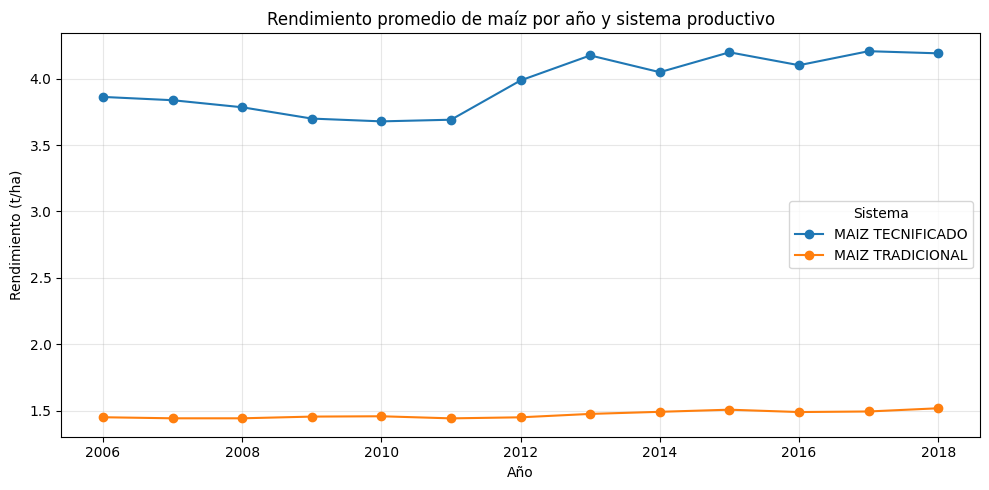

In [10]:
piv = maiz_final.groupby(['anio', 'desagregacion'])['rendimiento_tha'].mean().unstack()
ax = piv.plot(marker='o')
ax.set_title('Rendimiento promedio de maíz por año y sistema productivo')
ax.set_xlabel('Año'); ax.set_ylabel('Rendimiento (t/ha)')
ax.legend(title='Sistema')
plt.tight_layout(); plt.show()

**5.2 Departamentos con mayor rendimiento promedio**

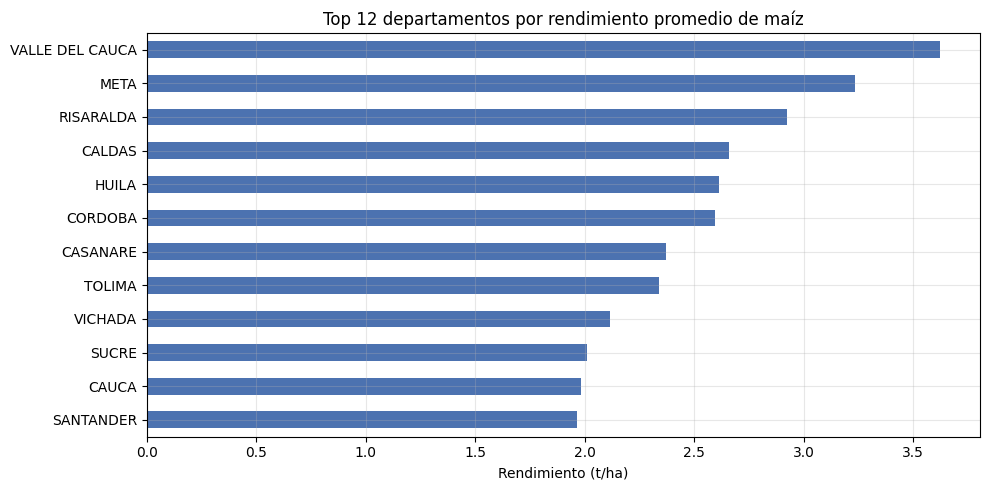

In [11]:
top_dep = (maiz_final.groupby('departamento')['rendimiento_tha']
           .mean().sort_values(ascending=False).head(12))
ax = top_dep.sort_values().plot(kind='barh', color='#4C72B0')
ax.set_title('Top 12 departamentos por rendimiento promedio de maíz')
ax.set_xlabel('Rendimiento (t/ha)'); ax.set_ylabel('')
plt.tight_layout(); plt.show()

**5.3 Distribución del rendimiento por sistema**

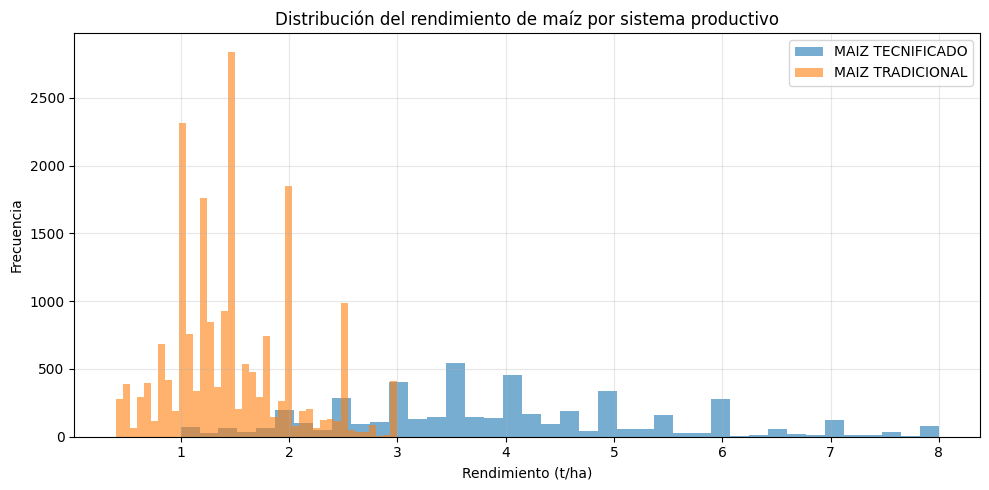

In [12]:
fig, ax = plt.subplots()
for sistema, g in maiz_final.groupby('desagregacion'):
    ax.hist(g['rendimiento_tha'], bins=40, alpha=0.6, label=sistema)
ax.set_title('Distribución del rendimiento de maíz por sistema productivo')
ax.set_xlabel('Rendimiento (t/ha)'); ax.set_ylabel('Frecuencia'); ax.legend()
plt.tight_layout(); plt.show()

**5.4 Rendimiento por semestre (A vs B)**

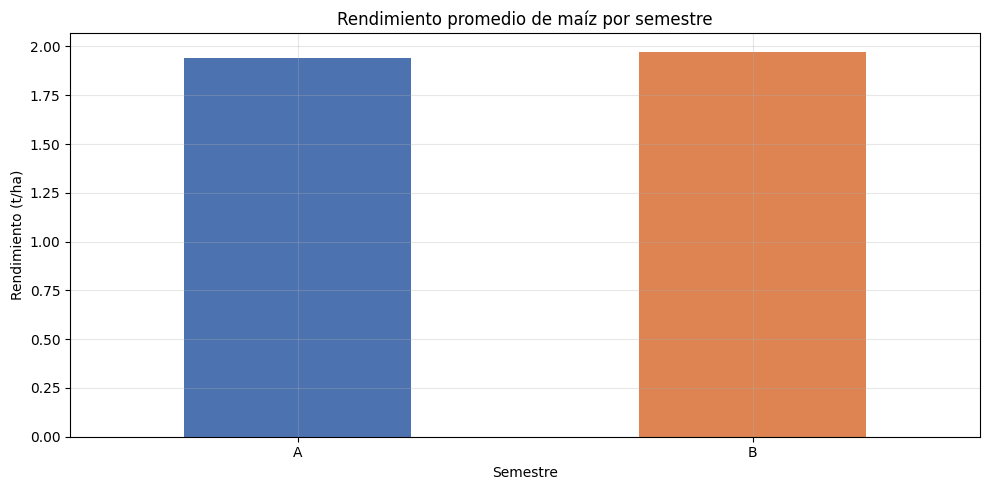

In [13]:
sem = maiz_final.dropna(subset=['semestre']).groupby('semestre')['rendimiento_tha'].mean()
ax = sem.plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_title('Rendimiento promedio de maíz por semestre')
ax.set_xlabel('Semestre'); ax.set_ylabel('Rendimiento (t/ha)')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**5.5 Siniestros por año** (plantilla para el módulo de riesgo)

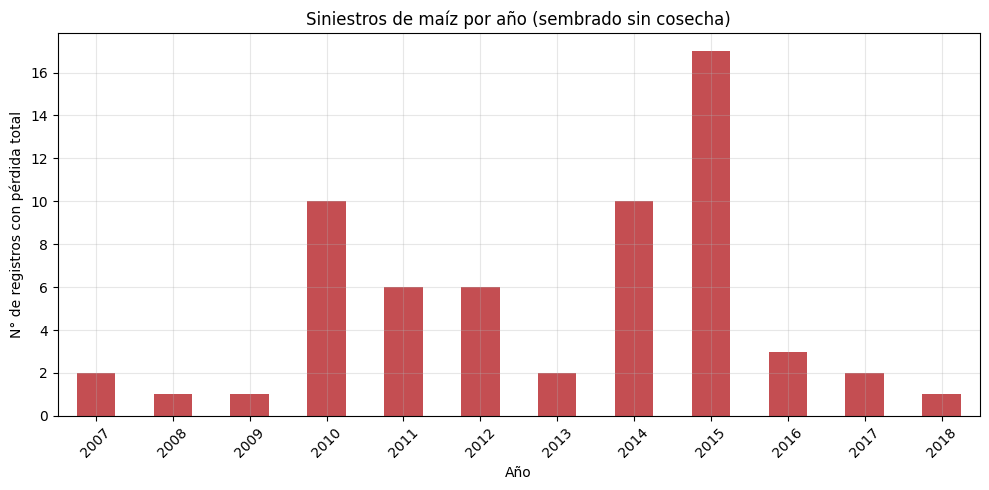

In [14]:
if len(siniestros) > 0:
    sin_anio = siniestros.groupby('anio').size()
    ax = sin_anio.plot(kind='bar', color='#C44E52')
    ax.set_title('Siniestros de maíz por año (sembrado sin cosecha)')
    ax.set_xlabel('Año'); ax.set_ylabel('N° de registros con pérdida total')
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()
else:
    print("No hay siniestros registrados para este cultivo.")

## 6. Exportar resultados

Guardamos dos archivos: el dataset analítico de rendimiento y el de siniestros.

In [15]:
ruta_maiz = os.path.join(DIR_SALIDA, "maiz_rendimiento_limpio.csv")
ruta_sin  = os.path.join(DIR_SALIDA, "maiz_siniestros.csv")

maiz_final.to_csv(ruta_maiz, index=False, encoding='utf-8')
siniestros[columnas_modelo].to_csv(ruta_sin, index=False, encoding='utf-8')

print(f"Guardado: {ruta_maiz}  ({len(maiz_final):,} filas)")
print(f"Guardado: {ruta_sin}  ({len(siniestros):,} filas)")
print()
print("IMPORTANTE al volver a cargar estos CSV, lee los códigos como texto")
print("para no perder los ceros iniciales (05, 05051):")
print("   pd.read_csv(ruta, dtype={'cod_dep': str, 'cod_mun': str})")

Guardado: datos_procesados/maiz_rendimiento_limpio.csv  (24,898 filas)
Guardado: datos_procesados/maiz_siniestros.csv  (61 filas)

IMPORTANTE al volver a cargar estos CSV, lee los códigos como texto
para no perder los ceros iniciales (05, 05051):
   pd.read_csv(ruta, dtype={'cod_dep': str, 'cod_mun': str})


## Siguiente paso: integrar el clima

Con `maiz_rendimiento_limpio.csv` listo, el siguiente módulo será **unir las variables climáticas**:

1. Obtener el **centroide (lat, lon) de cada municipio** (con `cod_mun` y un shapefile DANE).
2. Consultar **NASA POWER** (API) para temperatura, precipitación y radiación en ese punto.
3. **Agregar el clima por semestre** (acumulados y promedios de la temporada A o B), respetando la marca `semestre`.
4. Hacer el `merge` por `cod_mun + anio + semestre`.

> **Recuerda:** al cargar `maiz_rendimiento_limpio.csv` en el próximo módulo, usa
> `pd.read_csv(ruta, dtype={'cod_dep': str, 'cod_mun': str})` para conservar los ceros iniciales.

Eso produce la tabla final con la que se entrena el modelo de predicción de rendimiento.